In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn.functional as F
import transformers
import matplotlib.pyplot as plt
tokenizer = transformers.AutoTokenizer.from_pretrained("gpt2")

In [2]:
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")
vocab_size = 50257
seq_len = 1024
clean_data_seq = np.load("/dataset/david/discrete-mean-flow/text/owt_1sample_data/x0.npy")
# clean_data_seq_t = torch.randint(0, vocab_size, (seq_len,), device=device)
clean_data_seq_t = torch.from_numpy(clean_data_seq).to(device)
clean_data = F.one_hot(torch.Tensor(
                    clean_data_seq_t).long(), vocab_size).to(device).float()

In [3]:
torch.manual_seed(43)

tensor([[-0., -0., -0.,  ..., -0., -0., -0.]], device='cuda:7')
tensor(inf, device='cuda:7') tensor(1., device='cuda:7')
tensor(495.0492, device='cuda:7') tensor(0.9899, device='cuda:7')
tensor(247.5246, device='cuda:7') tensor(0.9798, device='cuda:7')
tensor(165.0164, device='cuda:7') tensor(0.9697, device='cuda:7')
tensor(123.7623, device='cuda:7') tensor(0.9596, device='cuda:7')
tensor(99.0099, device='cuda:7') tensor(0.9495, device='cuda:7')
tensor(82.5083, device='cuda:7') tensor(0.9394, device='cuda:7')
tensor(70.7214, device='cuda:7') tensor(0.9293, device='cuda:7')
tensor(61.8812, device='cuda:7') tensor(0.9192, device='cuda:7')
tensor(55.0055, device='cuda:7') tensor(0.9091, device='cuda:7')
tensor(49.5049, device='cuda:7') tensor(0.8990, device='cuda:7')
tensor(45.0045, device='cuda:7') tensor(0.8889, device='cuda:7')
tensor(41.2541, device='cuda:7') tensor(0.8788, device='cuda:7')
tensor(38.0807, device='cuda:7') tensor(0.8687, device='cuda:7')
tensor(35.3607, device='cuda:7

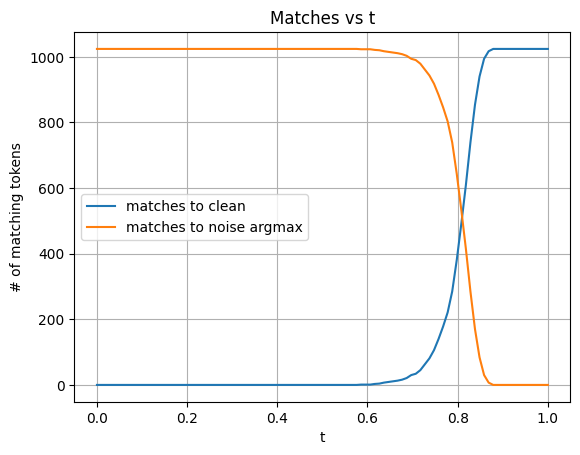

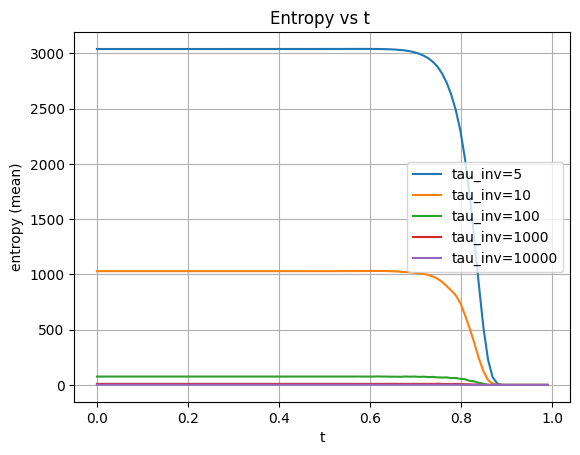

In [10]:
random_noise = torch.randn_like(clean_data)
# base tau for match-related calculations
base_tau_inverse = 10000
random_noise_prob = (random_noise * base_tau_inverse).softmax(dim=-1)
entropy = -(random_noise_prob * random_noise_prob.clamp_min(1e-12).log()).sum(dim=-1)
print(entropy)
random_noise_prob_seq = random_noise_prob.argmax(dim=-1)

t_vals = torch.linspace(1.0, 0.0001, 100, device=device)

# Matches plot (unchanged logic; uses base tau for the noise argmax reference)
num_matches_per_t = []
num_matches_per_t_2 = []
for t in t_vals:
    corrupted_data = t * clean_data + (1 - t) * random_noise
    corrupted_data_seq = corrupted_data.argmax(dim=-1)  # 1, 1024

    matches = (corrupted_data_seq == clean_data_seq_t)  # (T, B, L)
    num_matches = matches.sum(dim=-1)
    matches_2 = (corrupted_data_seq == random_noise_prob_seq)  # (T, B, L)
    num_matches_2 = matches_2.sum(dim=-1)

    num_matches_per_t.append(num_matches.item())
    num_matches_per_t_2.append(num_matches_2.item())

# Entropy plots for multiple tau_inverse values
entropy_per_t_by_tau = {}
tau_inv_list = [5, 10, 100, 1000, 10000]
for tau_inverse in tau_inv_list:
    entropy_per_t = []
    for t in t_vals:
        corrupted_data = t * clean_data + (1 - t) * random_noise
        scale = 1 / ((1-t))
        corrupted_data_prob = (corrupted_data * tau_inverse * scale).softmax(dim=-1)
        print(tau_inverse * scale, t)
        entropy = -(corrupted_data_prob * corrupted_data_prob.clamp_min(1e-12).log()).sum(dim=-1)
        ent_sum = entropy.sum().item()
        entropy_per_t.append(ent_sum)
    entropy_per_t_by_tau[tau_inverse] = entropy_per_t
    print(f"tau_inverse={tau_inverse} done")

t_axis = t_vals.detach().cpu().numpy()
plt.plot(t_axis, num_matches_per_t, label="matches to clean")
plt.plot(t_axis, num_matches_per_t_2, label="matches to noise argmax")
plt.xlabel("t")
plt.ylabel("# of matching tokens")
plt.title("Matches vs t")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for tau_inverse, entropy_per_t in entropy_per_t_by_tau.items():
    plt.plot(t_axis, entropy_per_t, label=f"tau_inv={tau_inverse}")
plt.xlabel("t")
plt.ylabel("entropy (mean)")
plt.title("Entropy vs t ")
plt.legend()
plt.grid(True)
plt.show()








In [62]:
num_matches = torch.tensor(num_matches_per_t)  # (T,)
full_len = clean_data_seq_t.shape[-1]          # 1024

# 1) 처음으로 1024가 깨지는 시점
first_nonfull_idx = (num_matches < full_len).nonzero(as_tuple=True)[0][0].item()

# 2) 그 이후 처음 0이 되는 시점
first_zero_idx = (num_matches == 0).nonzero(as_tuple=True)[0][0].item()

t_first_nonfull = t_vals[first_nonfull_idx].item()
t_first_zero = t_vals[first_zero_idx].item()

print(f"t where matches first drop below 1024 : {t_first_nonfull:.4f}")
print(f"t where matches first hit 0          : {t_first_zero:.4f}")
print(f"interval                             : "
      f"[{t_first_zero:.4f}, {t_first_nonfull:.4f}] "
      f"(descending t)")

t where matches first drop below 1024 : 0.8800
t where matches first hit 0          : 0.5800
interval                             : [0.5800, 0.8800] (descending t)


In [2]:
import datasets
# 1k subset for overfitting experiments
# Use the same 1k samples for both train and valid
# Reuses cached Skylion007/openwebtext data
dataset = datasets.load_dataset(
	'Skylion007/openwebtext',
	split='train[:1000]',
	cache_dir="/dataset/david/.cache/huggingface/datasets",
	streaming=False,
	trust_remote_code=True)

In [8]:
for i in range(1000):
	print(dataset[i])

{'text': 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.\n\nHe said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical t